In [2]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [3]:

#initial
TI0 = 31.5
TD0 = 0.0
TNI0 = 1.26
Integral_Zp0 = 0.0
L_scale = 1e9
L0 = 2.71E9/L_scale

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TD_value = torch.tensor([TD0], dtype=torch.float32, device=device)
TI_value = (torch.tensor([TI0], dtype=torch.float32, device=device))
TN_value = (torch.tensor([TNI0], dtype=torch.float32, device=device))
L_value = (torch.tensor([L0], dtype=torch.float32, device=device))
Integral_Zp = (torch.tensor([Integral_Zp0], dtype=torch.float32, device=device))

#Parameters
K = 1000
mu = 0.1
p1 = 1
p2 = 20
KL = 2E10/L_scale
s = 1.5E8/L_scale
delta_D = 0.2
delta_L = 0.033
D = 240
lamda = 0.1
kappa = 0.01
omega = 0.007
gamma = 0.03
r = 5
cCTLA4 = 2
PD1 = 2
cL = 1E8/L_scale


In [4]:
import math
eta_pl = 1
eta_L = 0.1
e_pl = 0.5
e_2pl  = 0.05
pT = 0.2
pL = 0.1
t_R = 3 #hours
alpha = 0.3
beta = 0.03
dose_Gy = 2.0
SF_D = math.exp(-(alpha*dose_Gy + beta*dose_Gy**2)) #summing lethal lesions plus the lethal lesion that were misrepaired

print ("SF_D = ", SF_D)


SF_D =  0.4867522559599717


In [5]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    #constructor that takes in the parameters for the model
    def __init__(self, t0, t1, y0,  input_size: int = 1, output_size: int = 5, hidden_layers: int = 5, hidden_nodes: int = 64):
        super().__init__()

        self.t0 = float(t0)                     # my leg starts here
        self.Lseg = float(t1 - t0)              # my leg is this many days long
        self.register_buffer("y0",torch.as_tensor(y0, dtype=torch.float32).reshape(1, -1))

        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    #This is the prediction function
    def forward(self, t: torch.Tensor):
        tau = (t - self.t0) / self.Lseg
        h = self.activation(self.inputs(tau))
        h = self._apply_model(h)
        h = self.outputs(h)
        return self.y0 + tau * h


In [6]:
import inspect
print(inspect.getsource(PINNModel.__init__))

    def __init__(self, t0, t1, y0,  input_size: int = 1, output_size: int = 5, hidden_layers: int = 5, hidden_nodes: int = 64):
        super().__init__()

        self.t0 = float(t0)                     # my leg starts here
        self.Lseg = float(t1 - t0)              # my leg is this many days long
        self.register_buffer("y0",torch.as_tensor(y0, dtype=torch.float32).reshape(1, -1))

        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear



In [7]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 100, 1000).reshape(-1, 1) #many data points

#creating points for physics loss
x_physics = torch.linspace(0, 100, 1000, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

In [8]:
# def fractionation(TI_value, TD_value, L_value):
#     TI_initial = TI_value
#     TD_initial = TD_value
#     L_initial = L_value
#     TI_value = TI_initial - (pT * TI_initial * (1 - SF_D))
#     TD_value = TD_initial + (pT * TI_initial * (1 - SF_D))
#     L_value = L_initial - (pT * L_initial * (1 - SF_D))
#     return TI_value, TD_value, L_value

def radiate(y):
    TD, TI, TNI, L, G = y
    TD_new = TD + (pT * TI * (1 - SF_D))
    TI_new = TI - (pT * TI * (1 - SF_D))
    L_new = L - (pL * L * (1 - SF_D))
    return TD_new, TI_new, TNI, L_new, G

# lesion_T = pT * (1.0 - SF_D)
# lesion_L = pL * (1.0 - SF_D)

def build_segments(dose_times, t_end, max_len=2.0):
    edges = sorted(set([0.0] + list(dose_times) + [t_end]))   # RULE 1: cut at every dose
    out = [edges[0]]
    for a, b in zip(edges[:-1], edges[1:]):                   # RULE 2: nothing over max_len
        n = max(1, int(np.ceil((b - a) / max_len)))
        out.extend(list(np.linspace(a, b, n + 1))[1:])
    return out

def schedule (n_fractions=10, start_day=0.0, weekdays_only=True):
    times, day = [], start_day
    while len(times) < n_fractions:
        if (not weekdays_only) or (day % 7 < 5):
            times.append(day)
        day += 1.0
    return times

DOSE_TIMES = schedule(n_fractions=2, start_day=0.0, weekdays_only=True)
T_END = 10.0

time_cuts = build_segments(DOSE_TIMES, T_END)


In [9]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
import copy

from sympy import false, true


Epochs = 20000
Length = 1e-3

# model = PINNModel().to(device) #create neural network
# optimize = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer for the model parameters


#data_loss = nn.MSELoss()

Epochs_first = 8000        # first segment starts from random weights
Epochs_rest  = 2500        # later ones start warm, so they need far fewer

trained_nets = []
spans = []
warm = None

y_now = np.array([TD0, TI0, TNI0, L0, Integral_Zp0])   # <-- THE MISSING LINE

for seg in range(len(time_cuts) - 1):              ### NEW OUTER LOOP ###
    t0, t1 = time_cuts[seg], time_cuts[seg + 1]

    if any(abs(t0 - d) < 1e-9 for d in DOSE_TIMES):
        y_now = radiate(y_now)                # <-- THE CLIFF. One line.

    model = PINNModel(t0, t1, y_now).to(device)
    if warm is not None:
        model.load_state_dict({k: v for k, v in warm.items() if k != "y0"}, strict=False)
    optimize = torch.optim.Adam(model.parameters(), lr=1e-3)
    x_physics = torch.linspace(t0, t1, 200, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

    #for loop that trains the model
    for epoch in range(Epochs):
        optimize.zero_grad() #reset the gradient to 0 at the start of each loop
        dosage = true
        #data loss
        # y_pred = model(x_data_t) #generates prediction
        # TD_pred = y_pred[:, 0:1] #extracts the first column of the prediction
        # TI_pred = y_pred[:, 1:2] #extracts the second column of the prediction
        #loss_data = data_loss(TD_pred, y_data_t[:, 0:1]) + data_loss(TI_pred, y_data_t[:, 1:2]) #compares prediction to the data points and calculates the loss

        prediction = model(x_physics) #generates prediction for physics points
        TD_physics = (prediction[:, 0:1])
        TI_physics = (prediction[:, 1:2])
        TNI_physics = (prediction[:, 2:3])
        L_physics = (prediction[:, 3:4])
        Integral_Zp_physics = (prediction[:, 4:5])


        T = TI_physics + TD_physics + TNI_physics
        T_safe = torch.clamp(T, min=1e-8)
        Zp = (omega * (L_physics / cL)) / (1 + ((kappa * (T_safe ** (2/3)) * (L_physics / cL)) / (1 + PD1)))
        Zs = (gamma * ((1 + cCTLA4)/(r + cCTLA4))) * Integral_Zp_physics#create another differential equation and solve it for the integration

        #TD loss
        #prediction = model(x_physics) #generates prediction for physics points
        #TD_physics = prediction[:, 0:1]
        dTD = ag.grad(TD_physics, x_physics, grad_outputs=torch.ones_like(TD_physics), create_graph=True)[0]  # calculates derivative
        Residual_TD = dTD + delta_D * TD_physics #calculates physics loss

        #TI Loss
        #TI_physics = prediction[:, 1:2] #generates prediction for physics points
        dTI = ag.grad(TI_physics, x_physics, grad_outputs=torch.ones_like(TI_physics), create_graph=True)[0]  # calculates derivative
        Residual_TI = dTI - (mu * TI_physics * (1 - ((TI_physics + TD_physics)/K)) - (Zp * TI_physics) - (Zs * TI_physics)) #calculates physics loss

        # #TNI Loss
        #TNI_physics = prediction[:, 2:3]
        dTNI = ag.grad(TNI_physics, x_physics, grad_outputs=torch.ones_like(TNI_physics), create_graph=True)[0]
        Residual_TNI = dTNI - ((mu * TNI_physics) * (1 - (TNI_physics/K)) - (Zp * TNI_physics) - (Zs * TNI_physics))


        #L Loss
        #L_physics = prediction[:, 3:4]
        dL = ag.grad(L_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
        Residual_L = dL - (lamda * (((p1 * (TI_physics + TNI_physics))/(K + TI_physics + TNI_physics)) + ((p2 * TD_physics)/(K + TD_physics))) * (L_physics) * (1 - (L_physics/KL)) + s - ((delta_L) * (L_physics)))
        #Residual_L = Residual_L*L_scale

        #Zs Loss
        dG = ag.grad(Integral_Zp_physics, x_physics, torch.ones_like(Integral_Zp_physics), create_graph=True)[0]
        Residual_G = dG - Zp


        # #nPL Loss
        # nPL_physics = prediction[:, 4:5]
        # dnPL = ag.grad(nPL_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
        # Residual_nPL = dnPL - ((nPL_physics) * (D) - (ePL) * (nPL_physics) - (e2PL) * (nPL_physics)**2)
        # loss_nPL = torch.mean(Residual_nPL**2) #calculates mean squared error for physics loss


        # #nL Loss
        # nL_physics = prediction[:, 5:6]
        # dnL = ag.grad(nL_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
        # Residual_nL = dnL - (((nL_physics) * (D) + (e2PL * (nPL_physics)**2)))
        # loss_nL = torch.mean(Residual_nL**2) #calculates mean squared error for physics loss

        loss_TD  = torch.mean((Residual_TD)**2)
        loss_TI  = torch.mean((Residual_TI)**2)
        loss_TNI = torch.mean((Residual_TNI)**2)
        loss_L  = torch.mean((Residual_L)**2)
        loss_Zs = torch.mean(Residual_G**2)

        #adding initial loss
        initial = model(torch.tensor([[0.0]], device=device, dtype=torch.float32)) #prediction at initial condition
        TI0_pred = initial[:, 1:2] 
        TD0_pred = initial[:, 0:1] 
        TNI0_pred = initial[:, 2:3] 
        L0_pred = initial[:, 3:4]
        Integral_Zp0_pred = initial[:, 4:5]
    
        # initial_loss = (
        # ((TD0_pred  - TD0))**2 +
        # ((TI0_pred  - TI0))**2 +
        # ((TNI0_pred - TNI0))**2 +
        # ((L0_pred - L0))**2 +
        # ((Integral_Zp0_pred - Integral_Zp))**2
        # ).mean()


        loss_physics = loss_TD + loss_TI + loss_TNI + loss_L #+ loss_nPL + loss_nL
        total_loss = loss_TD + (5 * loss_TI) + (5 * loss_TNI) + (5 * loss_L) + loss_Zs #+ (100 * initial_loss)

        total_loss = total_loss.mean()  # ensure scalar loss before backprop
        total_loss.backward()  # figures out what weights caused the error
        optimize.step() #fixes the model slightly to minimize error
        if epoch % 1000 == 0:
            print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Physics Loss: {loss_physics.item()}")

    with torch.no_grad():                      # THE HANDOFF
        y_now = model(torch.tensor([[t1]], device=device,dtype=torch.float32)).cpu().numpy().ravel()
    trained_nets.append(model)
    spans.append((t0, t1))
    warm = copy.deepcopy(model.state_dict())

Epoch: 0, Total Loss: 0.8758800029754639, Physics Loss: 0.720341145992279
Epoch: 1000, Total Loss: 1.2172241667940398e-06, Physics Loss: 9.298937015955744e-07
Epoch: 2000, Total Loss: 1.9041879113501636e-06, Physics Loss: 6.367282026076282e-07
Epoch: 3000, Total Loss: 2.996765715579386e-07, Physics Loss: 1.7395078089066374e-07
Epoch: 4000, Total Loss: 9.034347021952271e-05, Physics Loss: 1.979025182663463e-05
Epoch: 5000, Total Loss: 5.955608685326297e-06, Physics Loss: 1.3481836731443764e-06
Epoch: 6000, Total Loss: 4.2077849116139987e-07, Physics Loss: 1.6553197212942905e-07
Epoch: 7000, Total Loss: 5.641239113174379e-06, Physics Loss: 1.814146230572078e-06
Epoch: 8000, Total Loss: 1.1878875483262163e-07, Physics Loss: 9.739898843008632e-08
Epoch: 9000, Total Loss: 6.528543963213451e-06, Physics Loss: 1.5591115243296372e-06
Epoch: 10000, Total Loss: 3.0556257115677e-06, Physics Loss: 7.160750783441472e-07
Epoch: 11000, Total Loss: 4.4875168896396644e-06, Physics Loss: 1.1150762020406

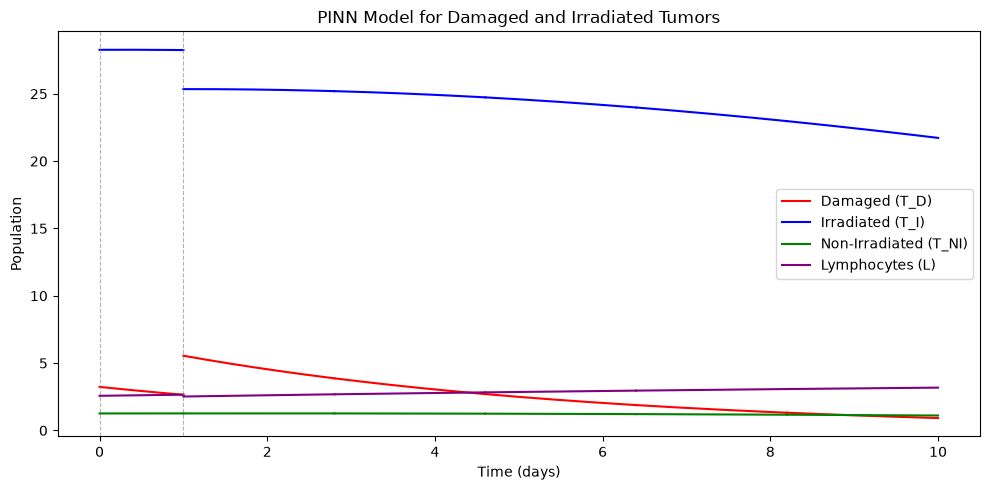

In [10]:
# #Testing the Model
# model.eval()
# x_test = x.detach().clone().to(device=device, dtype=torch.float32)
# y_pred = model(x_test).detach().cpu().numpy()#get Pinn Solution curve
# TD_pred = y_pred[:, 0]   # Extract the first column for TD predictions
# TI_pred = y_pred[:, 1]  # Extract the second column for TI predictions
# TNI_pred = y_pred[:, 2]  # Extract the third column for TNI predictions
# L_pred = y_pred[:, 3] # Extract the fourth column for L predictions

# #Plotting the Neural Network Model vs Analytical Solution
# plt.figure(figsize=(10, 5))
# plt.title("PINN Model for Damaged and Irradiated Tumors")
# plt.xlabel("Time (days)")
# plt.ylabel("Tumor Cells Population (cc)")


# plt.plot(x.cpu().numpy(), TD_pred, label="Damaged Tumors PINN Prediction", color="red")
# plt.plot(x.cpu().numpy(), TI_pred, label="Irridiated Tumors PINN Prediction", color="blue")
# plt.plot(x.cpu().numpy(), TNI_pred, label="Non-Irridiated Tumors PINN Prediction", color="green")
# plt.plot(x.cpu().numpy(), L_pred, label="Lymphocytes PINN Prediction", color="purple")

# plt.legend()
# plt.show()

labels = ["Damaged (T_D)", "Irradiated (T_I)", "Non-Irradiated (T_NI)", "Lymphocytes (L)"]
colors = ["red", "blue", "green", "purple"]

plt.figure(figsize=(10, 5))
plt.title("PINN Model for Damaged and Irradiated Tumors")
plt.xlabel("Time (days)")
plt.ylabel("Population")

for i, (net, (t0, t1)) in enumerate(zip(trained_nets, spans)):
    net.eval()
    t_seg = torch.linspace(t0, t1, 200, device=device,
                           dtype=torch.float32).reshape(-1, 1)
    with torch.no_grad():
        y_seg = net(t_seg).cpu().numpy()
    t_np = t_seg.cpu().numpy().ravel()
    for k in range(4):                      # cols 0–3 are populations; col 4 is the integral G
        plt.plot(t_np, y_seg[:, k], color=colors[k],
                 label=labels[k] if i == 0 else None)   # label only once

for d in DOSE_TIMES:                         # show where doses land
    plt.axvline(d, color="gray", ls="--", lw=0.8, alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()